# 5. The boundary operator spectrum

The subleading eigenvalues of the transfer matrix carry the second part of the conformal data. Their
phase gaps to the leading eigenvalue give the boundary scaling dimensions of the strip,

$$x_i - x_0 = \frac{v\,T\,\Delta\varphi_i}{\pi}.$$

Which tower appears depends on the boundary condition imposed by the quench state. The free boundary
selects the identity and $\epsilon$ towers, that is dimensions $1/2, 3/2, 2, 5/2, \dots$ above the
ground state.

One point applies throughout. The transfer matrix is non-normal, so an unconverged subspace can
produce Ritz values larger than the true spectrum. We therefore identify the physical branch by
continuity in $T$, never by largest modulus. The measurements use $k = 8$ eigenvalues per rung, from
the cluster tower arms.

In [1]:
include("../src/thesislib.jl")
using JLD2, Printf, Statistics
thesis_plot_theme!()

## The block method

A single vector converges to the leading eigenvalue only, so the boundary operators require a block
of $k$ states per side. `block_transfer_eigs` applies the transfer matrix to the whole block,
projects onto it and solves the resulting $k \times k$ generalised eigenproblem; `tower_dims`
converts the phase gaps into dimensions. Below we run $p = 0$ at $T = 3$ with $k = 4$.

In [2]:
mpo, scaffold = build_alcaraz_tmpo(3.0; p=0.0, dt=0.1, nbeta=4, column=:bulk5)
theta, L, R, info = block_transfer_eigs(mpo, scaffold; k=4, maxdim=32, eps_conv=1e-6, itermax=150)

i0 = argmax(abs.(theta))
xs = tower_dims(theta, 3.0, 2.0; i0=i0)      # v = 2 exactly at p = 0
@printf("|mu0| = %.5f\n", abs(theta[i0]))
@printf("dimensions from the phase gaps: %s\n", join([@sprintf("%.3f", x) for x in xs], "   "))
@printf("CFT, free boundary:             0.500   1.500   2.000\n")

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=638|"S=1/2,Site") <-> (dim=2|id=638|"S=1/2,Site")'


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=581|"Link,l=1") <-> (dim=3|id=413|"Link,l=2"), normdiff = 0.9446880731519559
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=870|"S=1/2,Site") <-> (dim=2|id=870|"S=1/2,Site")'


|mu0| = 1.49225
dimensions from the phase gaps: 0.477   1.452   1.925


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=41|"Link,l=1") <-> (dim=3|id=679|"Link,l=2"), normdiff = 0.10493384159131464
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


CFT, free boundary:             0.500   1.500   2.000


Three subleading eigenvalues give three dimensions, already within a few per cent of the Ising
values at a short time and a small block. The production runs use $k = 8$ and $\chi = 48$ on the
cluster, which reaches further up the tower and out to $T = 8$.

## The spectrum at every coupling

p=0.0  T=2,2.5,3,3.5,4,4.5,5,5.5,6,6.5,7,7.5,8
   last rung x1..x7 = 0.496  1.484  1.981  2.496  2.996  3.550  3.936


p=0.1  T=2,2.5,3,3.5,4,4.5,5,5.5,6,6.5,7,7.5,8
   last rung x1..x7 = 0.497  1.493  1.993  2.507  3.005  3.644  4.086
p=0.3  T=2,2.5,3,3.5,4,4.5,5,5.5,6
   last rung x1..x7 = 0.493  1.498  2.004  2.569  3.056  3.686  3.979
p=0.5  T=2,2.5,3,3.5,4,4.5
   last rung x1..x7 = 0.487  1.499  2.013  2.579  3.115  4.226  4.655


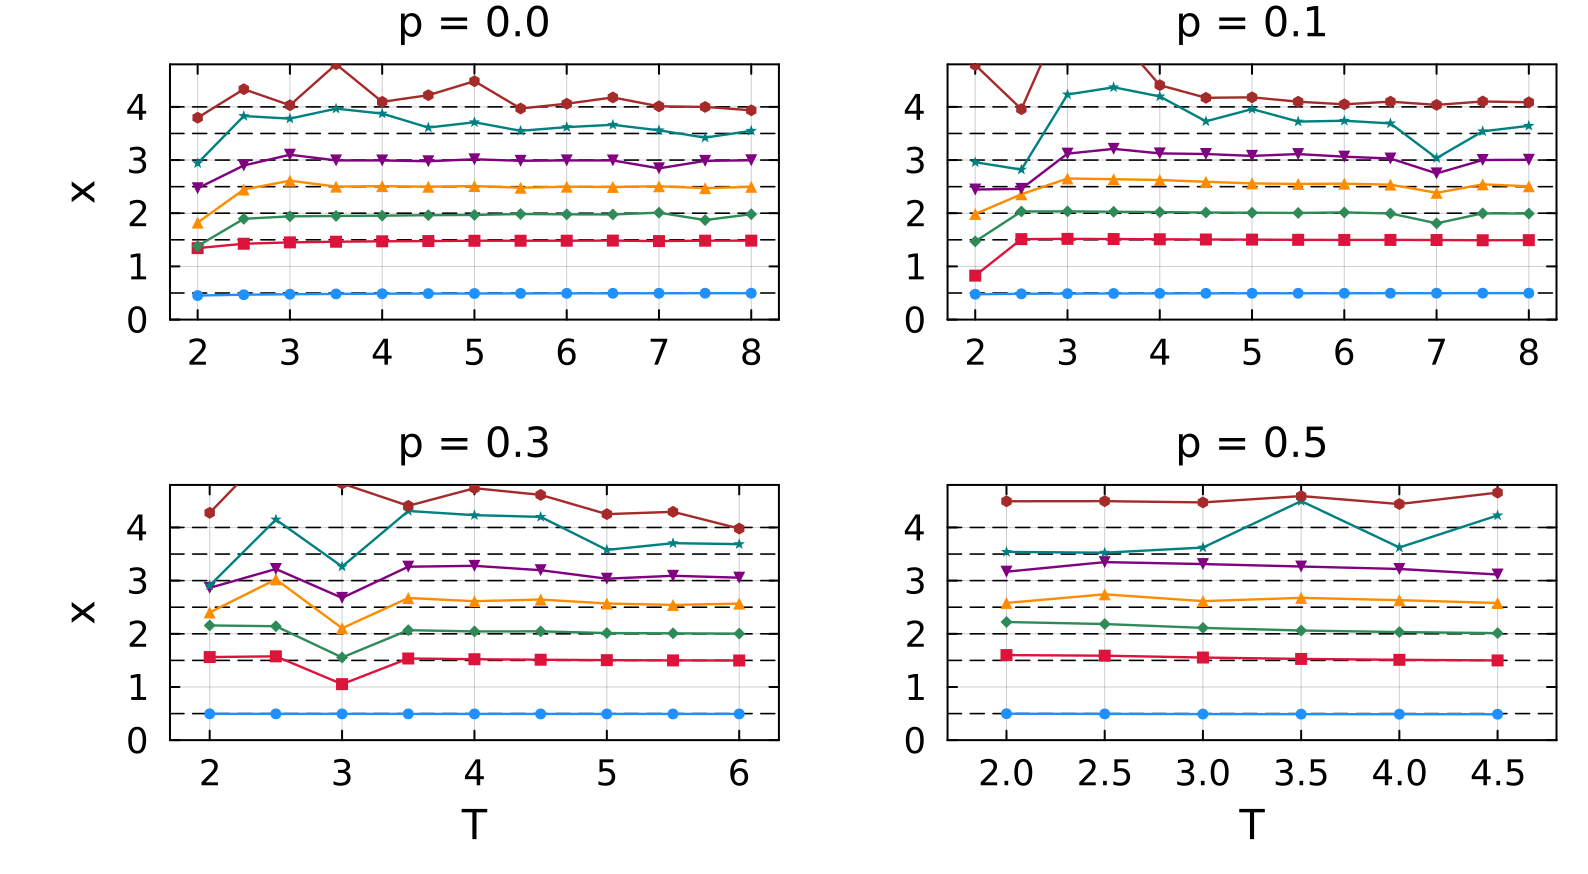

In [3]:
# the k = 8 cluster ladders, from data/cluster/sweep_tower_p*_bulk.jld2
include("../scripts/figures/fig_tower.jl")
make_tower()

The tower is the same at every coupling. Several levels are also degenerate, and with $k = 8$ the block resolves the multiplets, so the dimensions printed below
appear in near-equal pairs around the degenerate values.

In [4]:
# the degeneracies, seen in the raw dimensions of the last p=0 rung
a = Dict(k[2] => v for (k, v) in load("../data/cluster/sweep_tower_p0.0_bulk.jld2", "done")
         if k[1] == "tower_p0.0_bulk" && !haskey(v, :error))
T = maximum(keys(a))
e = a[T]
gaps = sort([abs(angle(t / e.theta[e.i0])) for (i, t) in enumerate(e.theta) if i != e.i0])
xs = 2.0 .* T .* gaps ./ pi
println("p=0, T=$T — all $(length(xs)) dimensions from the k=8 block:")
println(join([@sprintf("%.3f", x) for x in xs], "   "))
println("targets: 0.5, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0 — note the near-coincident values")

p=0, T=8.0 — all 7 dimensions from the k=8 block:


0.496   1.484   1.981   2.496   2.996   3.550   3.936
targets: 0.5, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0 — note the near-coincident values


## The four boundary pairs

At $p = 0$ we realised all four pairings of the Ising boundary conditions by making the top and
bottom boundary states of the strip independent. Each pair returns the tower CFT predicts for it.
The two mixed pairs, fixed-antifixed and free-fixed, have identical gap sequences $1, 2, 3, \dots$,
so the gaps alone cannot distinguish them.

(a) free--free         rungs T=3..9  last = 0.503, 1.488, 2.016
(b) fixed--fixed       rungs T=3..9  last = 1.974, 2.982, 3.961


(c) fixed--antifixed   rungs T=3..8  last = 0.994, 2.001, 3.045
(d) free--fixed        rungs T=3..8  last = 0.988, 1.969, 2.980


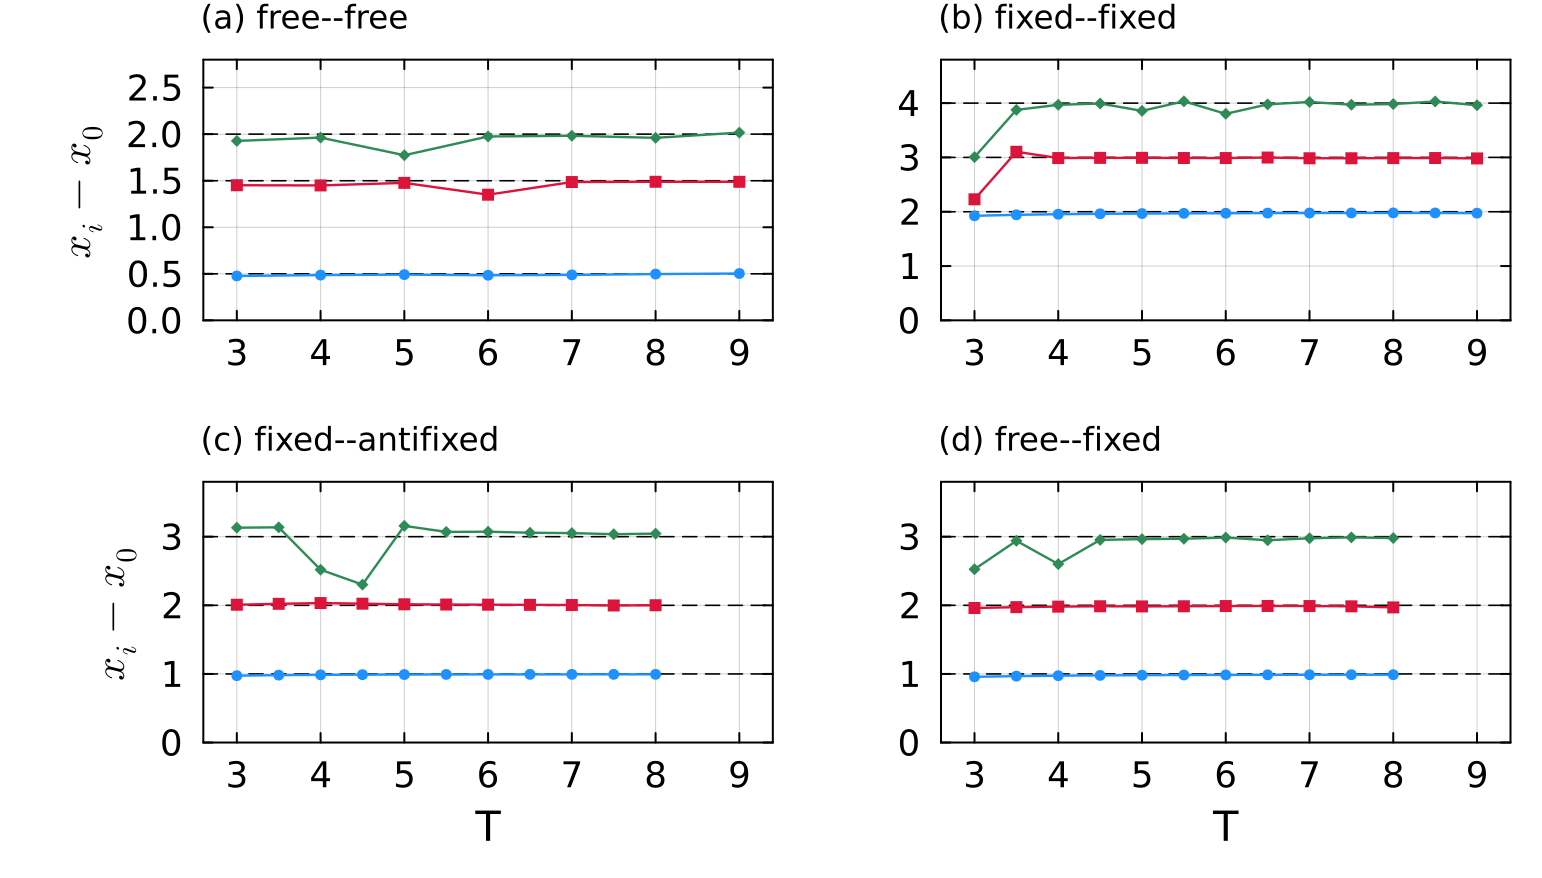

In [5]:
# the four boundary pairs at p = 0, from data/local/mixedbc_*.jld2
include("../scripts/figures/fig_bc_pairs.jl")
make_bc_pairs()

## The position of the tower

What distinguishes the two mixed pairs is the absolute position $x_0$, which the leading phase also
determines. We run the fit of notebook 4 backwards: $c$ and $v$ are known at $p = 0$, so the fitted
$1/T^2$ coefficient measures $x_0$.

| pair | $x_0$ measured | $x_0$ CFT |
|---|---|---|
| free-free | 0.002 | 0 |
| fixed-fixed | 0.002 | 0 |
| fixed-antifixed | 0.474 | 1/2 |
| free-fixed | 0.060 | 1/16 |

The gap tables for each pair and the $x_0$ fits are printed below.

In [6]:
# fits the leading phase backwards for x0, with c and v known at p = 0
include("../scripts/analysis/mixedbc_analysis.jl")

=== 1. the tower of each boundary pair, x_i - x_0 ===


┌ Warning: Assignment to `e` in soft scope is ambiguous because a global variable by the same name exists: `e` will be treated as a new local. Disambiguate by using `local e` to suppress this warning or `global e` to assign to the existing global variable.
└ @ ~/Desktop/masters/master-thesis-BSC/scripts/analysis/mixedbc_analysis.jl:50



free-free   (X+,X+)   predicted [0.5, 1.5, 2.0]
  T=3.0  |mu0|=1.492233  x-x0 = 0.477, 1.451, 1.927
  T=4.0  |mu0|=1.490545  x-x0 = 0.486, 1.449, 1.963
  T=5.0  |mu0|=1.489689  x-x0 = 0.491, 1.477, 1.774
  T=6.0  |mu0|=1.488809  x-x0 = 0.485, 1.350, 1.975
  T=7.0  |mu0|=1.488248  x-x0 = 0.488, 1.486, 1.983
  T=8.0  |mu0|=1.487882  x-x0 = 0.497, 1.489, 1.960
  T=9.0  |mu0|=1.487299  x-x0 = 0.503, 1.488, 2.016

fixed-fixed (Up,Up)   predicted [2.0, 3.0, 4.0]
  T=3.0  |mu0|=1.490772  x-x0 = 1.925, 2.229, 3.007
  T=3.5  |mu0|=1.489712  x-x0 = 1.943, 3.104, 3.875
  T=4.0  |mu0|=1.488861  x-x0 = 1.954, 2.989, 3.969
  T=4.5  |mu0|=1.488275  x-x0 = 1.962, 2.992, 3.992
  T=5.0  |mu0|=1.487492  x-x0 = 1.966, 2.992, 3.857
  T=5.5  |mu0|=1.487179  x-x0 = 1.970, 2.989, 4.033
  T=6.0  |mu0|=1.486790  x-x0 = 1.972, 2.989, 3.803
  T=6.5  |mu0|=1.486430  x-x0 = 1.975, 2.998, 3.977
  T=7.0  |mu0|=1.486050  x-x0 = 1.976, 2.984, 4.021
  T=7.5  |mu0|=1.485798  x-x0 = 1.978, 2.985, 3.971
  T=8.0  |mu0|=1.4

fixed-anti  (Up,Dn)    11       0.7125     0.4744     0.5000     2.2e-04
free-fixed  (X+,Up)    11       0.0619     0.0602     0.0625     1.8e-05


Together with the central charge of notebooks 3 and 4, the conformal data is complete. After a
critical quench of this non-integrable chain, transverse contraction gives $c$, the boundary
operator towers, their degeneracies and the absolute position of the tower, all from a single
transfer matrix. The integrable point served as the control at every stage.